# 02 – Formatting and Outliers
Decode categorical columns, fix numeric columns stored as text, and remove price outliers with the IQR rule.

**Input:** `housing_no_missing.csv` · **Output:** `data/processed/housing_no_outlier.csv`

In [1]:
import pandas as pd

housing_no_missing = pd.read_csv('../data/processed/housing_no_missing.csv', encoding='gbk')

## Decode categorical columns
Map the numeric codes in `elevator`, `subway`, `buildingStructure` and `renovationCondition` to readable labels.

In [2]:
housing_categorical = housing_no_missing.copy()

housing_categorical['elevator'] = housing_categorical['elevator'].replace({
    1: 'has elevator',
    0: 'no elevator'
})

housing_categorical['subway'] = housing_categorical['subway'].replace({
    1: 'has subway',
    0: 'no subway'
})

housing_categorical['buildingStructure'] = housing_categorical['buildingStructure'].replace({
    1: 'unknown',
    2: 'mixed',
    3: 'brick and wood',
    4: 'concrete',
    5: 'steel',
    6: 'steel-concrete composite'
})

housing_categorical['renovationCondition'] = housing_categorical['renovationCondition'].replace({
    1: 'other',
    2: 'rough',
    3: 'Simplicity',
    4: 'hardcover'
})
housing_categorical.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,高 26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,高 22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,中 4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,底 21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,中 6,1960,rough,mixed,0.333,no elevator,has subway,1


## Fix numeric columns stored as text
`constructionTime` and `floor` are stored as `object`. Inspect their unique values first:

In [3]:
print('constructionTime : ',housing_categorical.constructionTime.unique())
print('floor : ',housing_categorical.floor.unique())

constructionTime :  <StringArray>
['2005', '2004', '2008', '1960', '1997', '2009', '2006', '1991', '2001',
 '1990', '2011', '2000', '1998', '2010', '1996', '1993', '2002',   '未知',
 '2012', '1989', '2003', '2007', '1994', '1984', '1992', '2014', '1985',
 '2013', '1999', '1979', '1981', '1976', '1982', '1975', '1983', '1986',
 '1995', '1965', '1988', '1987', '2015', '1955', '1980', '1978', '1958',
 '1970', '1956', '1977', '1964', '1963', '1967', '2016', '1974', '1973',
 '1959', '1954', '1962', '1966', '1957', '1944', '1972', '1971', '1953',
 '1968', '1961', '1950', '1952', '1933', '1969', '1906', '1934', '1914']
Length: 72, dtype: str
floor :  <StringArray>
[ '高 26',  '高 22',   '中 4',  '底 21',   '中 6',   '中 8',   '高 6',  '高 10',
  '中 23',  '底 11',
 ...
 '未知 28',  '中 36', '未知 17', '未知 13',   '低 2', '未知 29', '未知 24', '未知 30',
 '未知 31',   '低 5']
Length: 201, dtype: str


- `constructionTime`: about 6% of the rows (19,283) contain a Chinese placeholder meaning *unknown*. These rows are dropped and the column is cast to `int`. (Imputing the mean or mode is a reasonable alternative; dropping is acceptable here because the share is small.)
- `floor`: each value is a Chinese floor-height label followed by the floor number. Only the number is kept.

In [4]:
housing_construction = housing_categorical.copy()

housing_construction = housing_construction[
    pd.to_numeric(
        housing_construction['constructionTime'],
        errors='coerce'
    ).notna()
]

housing_construction['constructionTime'] = (
    housing_construction['constructionTime'].astype(int)
)
housing_construction.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,高 26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,高 22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,中 4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,底 21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,中 6,1960,rough,mixed,0.333,no elevator,has subway,1


In [5]:
housing_floor = housing_construction.copy()

housing_floor['floor'] = (
    housing_floor['floor']
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

housing_floor.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.561978,39.877145,2016-12-11,1271.0,1030.0,198.00,3,2,1,3,4,2005,Simplicity,steel-concrete composite,0.500,has elevator,no subway,7
3,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
4,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1


In [6]:
housing_floor.info()

<class 'pandas.DataFrame'>
Index: 299536 entries, 0 to 318817
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Lng                  299536 non-null  float64
 1   Lat                  299536 non-null  float64
 2   tradeTime            299536 non-null  str    
 3   DOM                  299536 non-null  float64
 4   totalPrice           299536 non-null  float64
 5   square               299536 non-null  float64
 6   livingRoom           299536 non-null  int64  
 7   drawingRoom          299536 non-null  int64  
 8   kitchen              299536 non-null  int64  
 9   bathRoom             299536 non-null  int64  
 10  floor                299536 non-null  int64  
 11  constructionTime     299536 non-null  int64  
 12  renovationCondition  299536 non-null  object 
 13  buildingStructure    299536 non-null  object 
 14  ladderRatio          299536 non-null  float64
 15  elevator             299536 non-n

## Remove price outliers (IQR rule)
Rows whose `totalPrice` lies outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` are removed. The box plot below shows the distribution before removal.

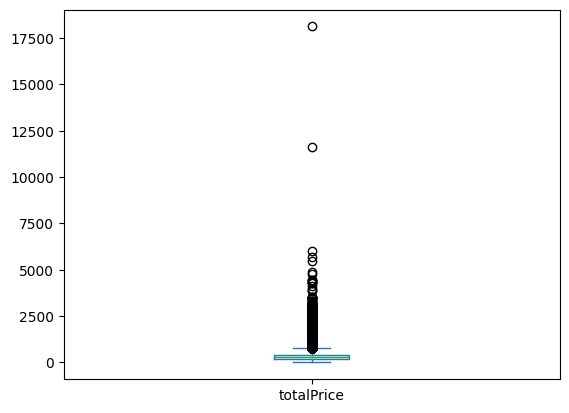

In [7]:
housing_floor.totalPrice.plot(kind = 'box');

In [8]:
Q1 = housing_floor['totalPrice'].quantile(0.25)
Q3 = housing_floor['totalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

housing_no_outlier = housing_floor[
    (housing_floor['totalPrice'] >= lower) &
    (housing_floor['totalPrice'] <= upper)
]

print('Number of removed outliers : ', housing_floor.shape[0] - housing_no_outlier.shape[0])

Number of removed outliers :  14496


Distribution after removal:

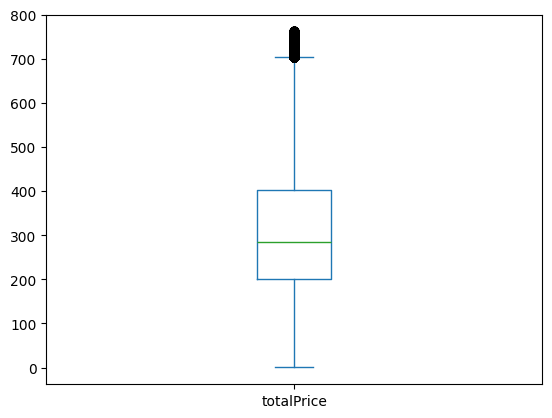

In [9]:
housing_no_outlier.totalPrice.plot(kind = 'box');

## Save

In [10]:
housing_no_outlier.to_csv('../data/processed/housing_no_outlier.csv', encoding='gbk', index=False)